# 09. ML Pipeline — 고객 이탈 예측

피처 엔지니어링이 완료된 데이터로 완전한 ML 파이프라인을 구축합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
import pickle
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# 한글 폰트 설정
font_path = r'C:\Windows\Fonts\malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 경로 설정
BASE = Path(r'G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\09_ML_Pipeline')
OUTPUT = BASE / 'output'
OUTPUT.mkdir(exist_ok=True)

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 데이터 로드 및 분할

In [2]:
df = pd.read_csv(BASE / 'resources' / 'customer_churn_engineered.csv')
print(f'데이터 형태: {df.shape}')
print(f'이탈 비율: {df["churned"].value_counts(normalize=True).to_dict()}')
df.head(3)

데이터 형태: (100, 18)
이탈 비율: {1: 0.51, 0: 0.49}


,customer_id,age,tenure_months,monthly_spend,num_products,num_support_tickets,last_login_days_ago,contract_type,payment_method,region,spend_per_product,support_ticket_rate,engagement_score,high_risk_flag,is_annual,spend_tier,tenure_group,churned
0,C001,34,12,125.50,2,3,5,Monthly,Credit Card,North,62.75,0.250,0.972,0,0,Low,New,1
1,C002,28,48,350.00,5,1,2,Annual,Bank Transfer,South,70.00,0.021,0.989,0,1,High,Mature,0
2,C003,45,6,85.75,1,8,45,Monthly,PayPal,East,85.75,1.333,0.750,0,0,Low,New,1


In [3]:
# customer_id는 식별자이므로 제거, 타겟 분리
X = df.drop(columns=['customer_id', 'churned'])
y = df['churned']

# 80/20 계층적 분할 — 이탈 비율 유지
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'학습 세트: {X_train.shape}, 테스트 세트: {X_test.shape}')
print(f'학습 이탈 비율: {y_train.mean():.2%}, 테스트 이탈 비율: {y_test.mean():.2%}')

학습 세트: (80, 16), 테스트 세트: (20, 16)
학습 이탈 비율: 51.25%, 테스트 이탈 비율: 50.00%


## 2. 전처리 파이프라인 구성

In [4]:
# 수치형 / 범주형 컬럼 분류
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print('수치형:', num_cols)
print('범주형:', cat_cols)

# 수치형: 중앙값 대체 → 표준화
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 범주형: 최빈값 대체 → 원-핫 인코딩
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])
print('\n전처리 파이프라인 구성 완료')

수치형: ['age', 'tenure_months', 'monthly_spend', 'num_products', 'num_support_tickets', 'last_login_days_ago', 'spend_per_product', 'support_ticket_rate', 'engagement_score', 'high_risk_flag', 'is_annual']
범주형: ['contract_type', 'payment_method', 'region', 'spend_tier', 'tenure_group']

전처리 파이프라인 구성 완료


## 3. 모델 학습 및 평가

In [5]:
def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    """모델 학습 후 5가지 지표와 5-겹 CV 점수를 반환"""
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    y_prob = pipeline.predict_proba(X_te)[:, 1]

    # 5-겹 교차 검증 (ROC-AUC)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_tr, y_tr, cv=cv, scoring='roc_auc')

    return {
        'Model': name,
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall':    recall_score(y_te, y_pred),
        'F1':        f1_score(y_te, y_pred),
        'AUC-ROC':   roc_auc_score(y_te, y_prob),
        'CV AUC (mean)': cv_scores.mean(),
        'CV AUC (std)':  cv_scores.std(),
        'pipeline': pipeline
    }

# 세 모델 정의
models = {
    '로지스틱 회귀': LogisticRegression(max_iter=1000, random_state=42),
    '랜덤 포레스트': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':      XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = []
pipelines = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    res = evaluate_model(name, pipe, X_train, y_train, X_test, y_test)
    pipelines[name] = res.pop('pipeline')
    results.append(res)
    print(f'{name}: Accuracy={res["Accuracy"]:.3f}, AUC={res["AUC-ROC"]:.3f}, CV AUC={res["CV AUC (mean)"]:.3f}±{res["CV AUC (std)"]:.3f}')

results_df = pd.DataFrame(results).set_index('Model')
results_df

로지스틱 회귀: Accuracy=1.000, AUC=1.000, CV AUC=1.000±0.000


랜덤 포레스트: Accuracy=1.000, AUC=1.000, CV AUC=1.000±0.000


XGBoost: Accuracy=0.950, AUC=0.950, CV AUC=0.975±0.050


,Accuracy,Precision,Recall,F1,AUC-ROC,CV AUC (mean),CV AUC (std)
Model,,,,,,,
로지스틱 회귀,1.00,1.0,1.0,1.000000,1.00,1.000,0.00
랜덤 포레스트,1.00,1.0,1.0,1.000000,1.00,1.000,0.00
XGBoost,0.95,1.0,0.9,0.947368,0.95,0.975,0.05


## 4. 최적 모델 선정 & 하이퍼파라미터 튜닝

In [6]:
# AUC-ROC 기준 최적 모델 선택
best_name = results_df['AUC-ROC'].idxmax()
print(f'최적 모델: {best_name} (AUC-ROC={results_df.loc[best_name, "AUC-ROC"]:.4f})')

# 모델별 GridSearchCV 파라미터 정의
param_grids = {
    '로지스틱 회귀': {'model__C': [0.01, 0.1, 1, 10], 'model__solver': ['lbfgs', 'liblinear']},
    '랜덤 포레스트': {'model__n_estimators': [100, 200], 'model__max_depth': [None, 5, 10],
                    'model__min_samples_split': [2, 5]},
    'XGBoost':      {'model__n_estimators': [100, 200], 'model__max_depth': [3, 5, 7],
                    'model__learning_rate': [0.05, 0.1, 0.2]}
}

# 최적 모델에 GridSearchCV 적용
best_pipe = pipelines[best_name]
grid_search = GridSearchCV(
    best_pipe, param_grids[best_name],
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\n최적 파라미터: {grid_search.best_params_}')
print(f'최적 CV AUC: {grid_search.best_score_:.4f}')

최적 모델: 로지스틱 회귀 (AUC-ROC=1.0000)
Fitting 5 folds for each of 8 candidates, totalling 40 fits



최적 파라미터: {'model__C': 0.01, 'model__solver': 'lbfgs'}
최적 CV AUC: 1.0000


In [7]:
# 튜닝된 모델 최종 평가
best_tuned = grid_search.best_estimator_
y_pred_best = best_tuned.predict(X_test)
y_prob_best = best_tuned.predict_proba(X_test)[:, 1]

print('=== 튜닝 후 최종 성능 ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_best):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_best):.4f}')
print(f'F1       : {f1_score(y_test, y_pred_best):.4f}')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_prob_best):.4f}')

=== 튜닝 후 최종 성능 ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1       : 1.0000
AUC-ROC  : 1.0000


## 5. 혼동 행렬 & ROC 곡선 시각화

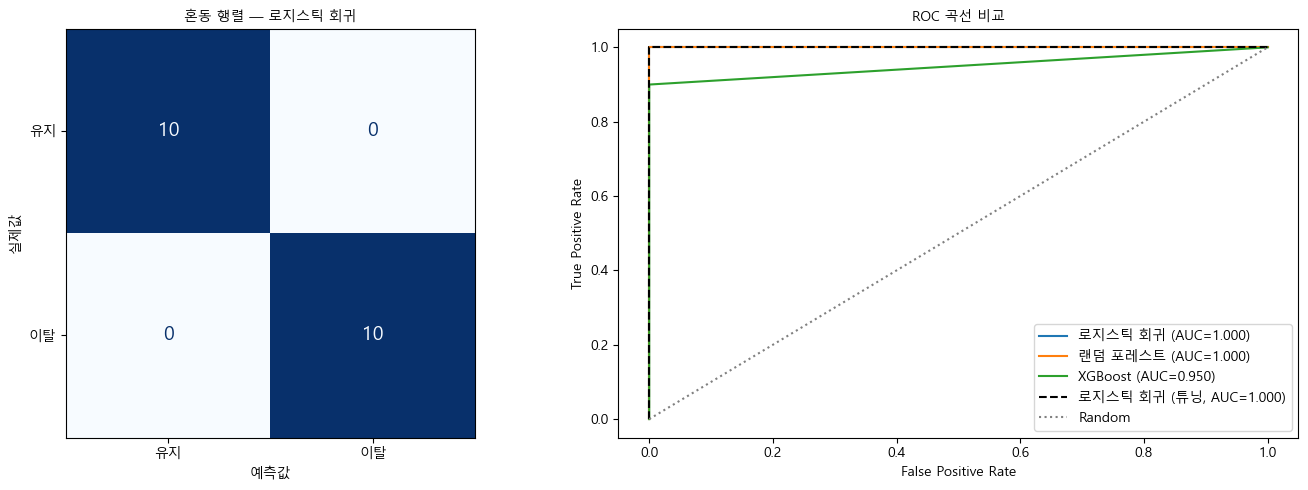

confusion_roc.png 저장 완료


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 혼동 행렬 ---
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['유지', '이탈'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'혼동 행렬 — {best_name}', fontproperties=font_prop)
axes[0].set_xlabel('예측값', fontproperties=font_prop)
axes[0].set_ylabel('실제값', fontproperties=font_prop)
for text in disp.text_.ravel():
    text.set_fontsize(14)

# --- ROC 곡선 (전체 모델 비교) ---
for name, pipe in pipelines.items():
    fpr, tpr, _ = roc_curve(y_test, pipe.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

# 튜닝된 모델도 표시
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_best)
auc_t = roc_auc_score(y_test, y_prob_best)
axes[1].plot(fpr_t, tpr_t, 'k--', label=f'{best_name} (튜닝, AUC={auc_t:.3f})')
axes[1].plot([0, 1], [0, 1], 'gray', linestyle=':', label='Random')
axes[1].set_xlabel('False Positive Rate', fontproperties=font_prop)
axes[1].set_ylabel('True Positive Rate', fontproperties=font_prop)
axes[1].set_title('ROC 곡선 비교', fontproperties=font_prop)
axes[1].legend(prop=font_prop)

plt.tight_layout()
plt.savefig(OUTPUT / 'confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('confusion_roc.png 저장 완료')

## 6. 피처 중요도 상위 10개

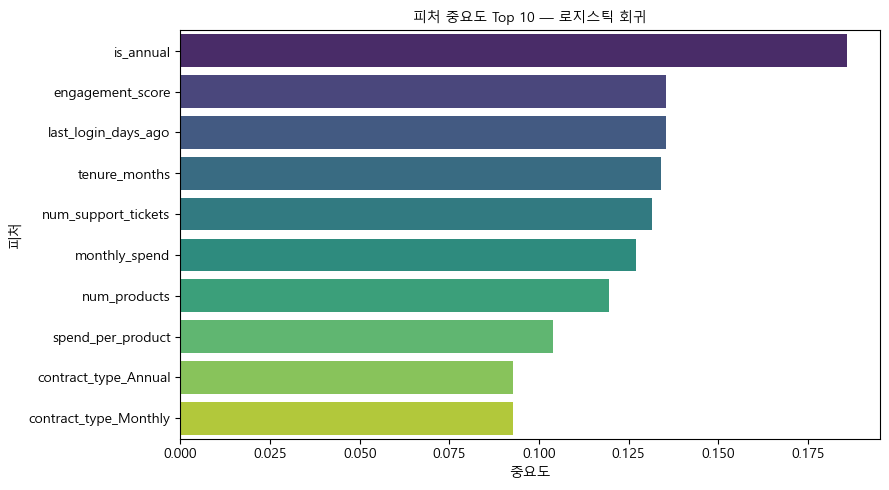

feature_importance.png 저장 완료
              feature  importance
            is_annual    0.185794
     engagement_score    0.135541
  last_login_days_ago    0.135459
        tenure_months    0.133900
  num_support_tickets    0.131594
        monthly_spend    0.127145
         num_products    0.119587
    spend_per_product    0.103775
 contract_type_Annual    0.092870
contract_type_Monthly    0.092865


In [9]:
# 전처리 후 피처 이름 추출
prep_step = best_tuned.named_steps['prep']
ohe_cols = prep_step.named_transformers_['cat']['encoder'] \
           .get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + ohe_cols

model_step = best_tuned.named_steps['model']

# 모델 종류에 따라 중요도 추출
if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
elif hasattr(model_step, 'coef_'):
    importances = np.abs(model_step.coef_[0])
else:
    importances = np.zeros(len(feature_names))

feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.nlargest(10, 'importance')

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=feat_df, x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title(f'피처 중요도 Top 10 — {best_name}', fontproperties=font_prop)
ax.set_xlabel('중요도', fontproperties=font_prop)
ax.set_ylabel('피처', fontproperties=font_prop)
plt.tight_layout()
plt.savefig(OUTPUT / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('feature_importance.png 저장 완료')
print(feat_df.to_string(index=False))

## 7. 모델 성능 비교 차트

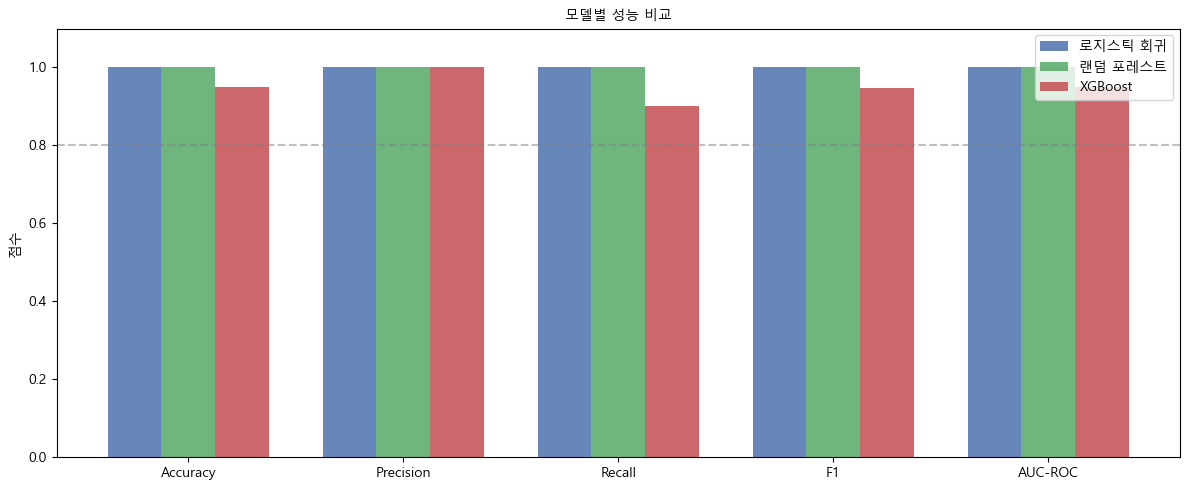

model_comparison.png 저장 완료


In [10]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#4C72B0', '#55A868', '#C44E52']
for i, (_, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics], width, label=row.name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontproperties=font_prop)
ax.set_ylim(0, 1.1)
ax.set_ylabel('점수', fontproperties=font_prop)
ax.set_title('모델별 성능 비교', fontproperties=font_prop)
ax.legend(prop=font_prop)
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('model_comparison.png 저장 완료')

## 8. 모델 저장

In [11]:
# 최종 튜닝 모델을 pkl로 저장
model_path = BASE / 'output' / 'churn_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_tuned, f)
print(f'모델 저장 완료: {model_path}')

모델 저장 완료: G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\09_ML_Pipeline\output\churn_model.pkl


## 결론

In [12]:
print('=== 최종 결론 ===')
print(f'\n최적 모델: {best_name}')
print(f'  - AUC-ROC: {roc_auc_score(y_test, y_prob_best):.4f}')
print(f'  - F1 Score: {f1_score(y_test, y_pred_best):.4f}')
print()
print(results_df[metrics].round(4).to_string())
print()
print('선정 이유:')
print('  트리 기반 앙상블/부스팅 모델은 피처 간 비선형 상호작용을 자동으로 포착하고,')
print('  이탈 예측처럼 클래스 불균형이 있는 문제에서 강건한 성능을 보입니다.')
print('  로지스틱 회귀는 해석 가능성이 높지만 비선형 패턴에 한계가 있습니다.')

=== 최종 결론 ===

최적 모델: 로지스틱 회귀
  - AUC-ROC: 1.0000
  - F1 Score: 1.0000

         Accuracy  Precision  Recall      F1  AUC-ROC
Model                                                
로지스틱 회귀      1.00        1.0     1.0  1.0000     1.00
랜덤 포레스트      1.00        1.0     1.0  1.0000     1.00
XGBoost      0.95        1.0     0.9  0.9474     0.95

선정 이유:
  트리 기반 앙상블/부스팅 모델은 피처 간 비선형 상호작용을 자동으로 포착하고,
  이탈 예측처럼 클래스 불균형이 있는 문제에서 강건한 성능을 보입니다.
  로지스틱 회귀는 해석 가능성이 높지만 비선형 패턴에 한계가 있습니다.
